In [1]:
from google.colab import drive
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
execfile('/content/drive/MyDrive/Mineria de datos/Mineria de datos/NuestrasFunciones.py')

In [4]:
import pandas as pd
import numpy as np

vinosDep = pd.read_hdf(r'/content/drive/MyDrive/Mineria de datos/Mineria de datos/PARTE I_Depuracion y Regresiones/Dia1_MDDepuracion/DatosVinoDep_winsRand.h5','df')

vinosDep.head()

,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region,n_missings,Beneficio,Compra
0,2,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,16.2,2,1.00,M,***,Reg 1,1,515,1
1,4,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,3,3.38,M,***,Reg 3,0,585,1
2,8,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,3,3.72,R,Desc,Reg 1,0,0,0
3,11,-1.22,0.34,1.40,0.040,1.03236,3.20,0.09,11.6,2,6.23,B,***,Reg 2,1,775,1
4,12,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,1,2.44,R,Desc,Reg 2,0,596,1


In [5]:
vinosDep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6365 entries, 0 to 6364
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   int64   
 1   Acidez          6365 non-null   float64 
 2   AcidoCitrico    6365 non-null   float64 
 3   Azucar          6365 non-null   float64 
 4   CloruroSodico   6365 non-null   float64 
 5   Densidad        6365 non-null   float64 
 6   pH              6365 non-null   float64 
 7   Sulfatos        6365 non-null   float64 
 8   Alcohol         6365 non-null   float64 
 9   CalifProductor  6365 non-null   int64   
 10  PrecioBotella   6365 non-null   float64 
 11  Etiqueta        6365 non-null   category
 12  Clasificacion   6365 non-null   category
 13  Region          6365 non-null   category
 14  n_missings      6365 non-null   int64   
 15  Beneficio       6365 non-null   int64   
 16  Compra          6365 non-null   category
dtypes: category(4), flo

In [6]:
vinosDep["Clasificacion"].sort_values()

,Clasificacion
3182,*
1527,*
4098,*
1524,*
4102,*
...,...
3749,Desc
3751,Desc
5229,Desc
754,Desc


In [7]:
vinosDep["Clasificacion"] = vinosDep["Clasificacion"].cat.reorder_categories(['Desc','*','**','***','****'])

In [8]:
vinosDep['aleatorio'] = np.random.uniform(0,1,size=vinosDep.shape[0])
vinosDep['aleatorio2'] = np.random.uniform(0,1,size=vinosDep.shape[0])
vinosDep.head()

,ID,Acidez,AcidoCitrico,Azucar,CloruroSodico,Densidad,pH,Sulfatos,Alcohol,CalifProductor,PrecioBotella,Etiqueta,Clasificacion,Region,n_missings,Beneficio,Compra,aleatorio,aleatorio2
0,2,0.16,-0.81,26.10,-0.425,1.02792,3.38,0.70,16.2,2,1.00,M,***,Reg 1,1,515,1,0.615693,0.028365
1,4,2.64,-0.88,14.80,0.037,0.99518,3.12,0.48,22.0,3,3.38,M,***,Reg 3,0,585,1,0.872696,0.933471
2,8,0.29,-0.40,21.50,0.060,0.99572,3.49,1.21,10.3,3,3.72,R,Desc,Reg 1,0,0,0,0.680569,0.158144
3,11,-1.22,0.34,1.40,0.040,1.03236,3.20,0.09,11.6,2,6.23,B,***,Reg 2,1,775,1,0.317279,0.129169
4,12,0.27,1.05,11.25,-0.007,0.99620,4.93,0.26,15.0,1,2.44,R,Desc,Reg 2,0,596,1,0.908968,0.374004


In [9]:
# Extract the target variable
varObjBin = vinosDep.Compra
imputDep = vinosDep.drop(['ID','Beneficio','Compra'],axis=1)

## Descriptive Study of Relationships with the Response

In this section, we will attempt to discover a priori the marginal relationships of the variables with the binary target variable in order to get an idea of which of them will be potentially influential in the logistic regression models we fit.


In [10]:
# Apply the function to all variables to the target variable
tablaCramer = pd.DataFrame(imputDep.apply(lambda x: cramers_v(x,varObjBin)),columns=['VCramer'])

# Graph
import plotly.express as px
px.bar(tablaCramer,x=tablaCramer.VCramer,title='Relation with "Compra"').update_yaxes(categoryorder="total ascending").show()


In this case, the tentative variables for modeling are:

- Classification
- Producer Rating
- Acidity
- Sodium Chloride

From here on, we already have n_missings, and we begin to suspect that beyond this one, the relationships may be purely coincidental... but this will need to be confirmed in the model.




## Visual Exploration of Relationships

We will now use the graphical functions to plot the relationships of the variables with the binary target variable.

<Figure size 640x480 with 0 Axes>

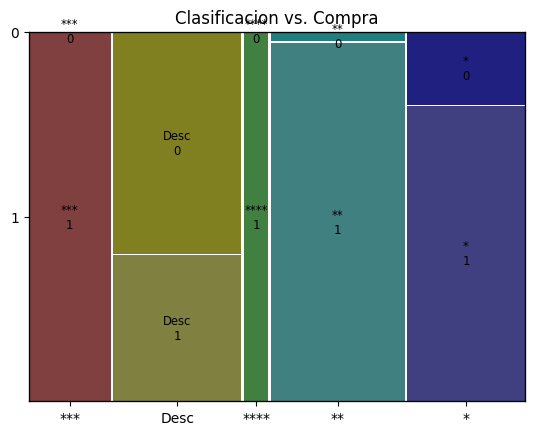

<Figure size 640x480 with 0 Axes>

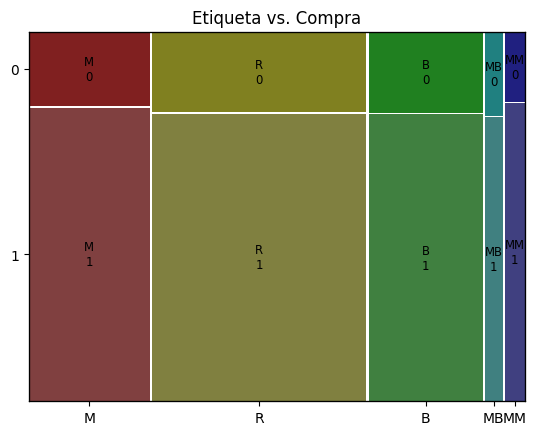

<Figure size 640x480 with 0 Axes>

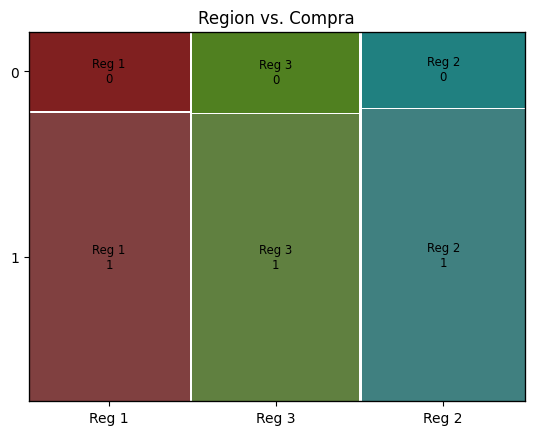

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.mosaicplot import mosaic

plt.clf()
#mosaic(pd.crosstab(vinosDep.Clasificacion, varObjBin))
mosaic(vinosDep,['Clasificacion','Compra'],gap=0.005, title='Clasificacion vs. Compra')
#sns.heatmap(pd.crosstab(vinosDep.Etiqueta, varObjBin))
plt.show()

plt.clf()
#mosaic(pd.crosstab(vinosDep.Clasificacion, varObjBin))
mosaic(vinosDep,['Etiqueta','Compra'],gap=0.005, title='Etiqueta vs. Compra')
#sns.heatmap(pd.crosstab(vinosDep.Etiqueta, varObjBin))
plt.show()

plt.clf()
#mosaic(pd.crosstab(vinosDep.Clasificacion, varObjBin))
mosaic(vinosDep,['Region','Compra'],gap=0.005, title='Region vs. Compra')
#sns.heatmap(pd.crosstab(vinosDep.Etiqueta, varObjBin))
plt.show()


As we already intuited from the Cramér's V chart, the Region variable does not discriminate at all against wine purchase (our binary target), since the distributions of 0 and 1 across the different regions are very similar, around 20/80%?

On the other hand, the "Clasificacion" variable has a lot to contribute, as we can see that the distributions of 0 and 1 across the different classification levels are very distinct. Thus, we begin to sense that wines with an Unknown classification seem to be generally poor wines, at least in the sense that they are not purchased. There appears to be a relatively increasing relationship between the proportion of purchase and the increase in classification stars. At this point, we can already start thinking that the *** and **** classifications have minimal differences with respect to the response, so they are candidates for merging if we wish to reduce the number of model parameters.


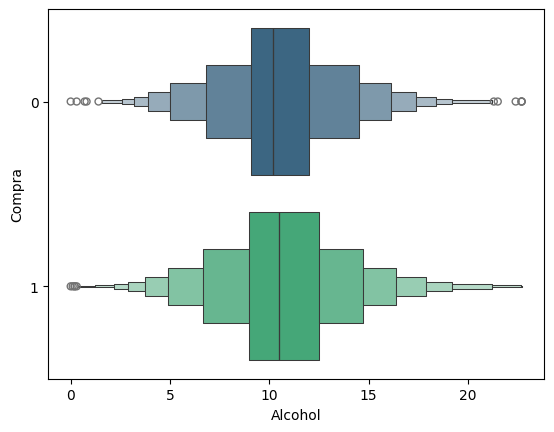

In [12]:
plt.clf()
sns.boxenplot(x='Alcohol',y='Compra',data=vinosDep,palette='viridis')
plt.show()


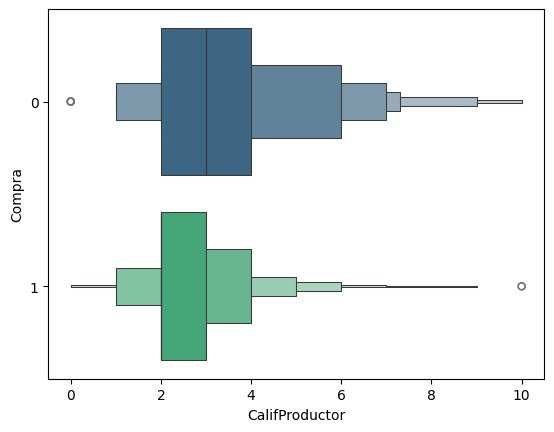

In [13]:
plt.clf()
sns.boxenplot(x='CalifProductor',y='Compra',data=vinosDep,palette='viridis')
plt.show()


<Figure size 640x480 with 0 Axes>

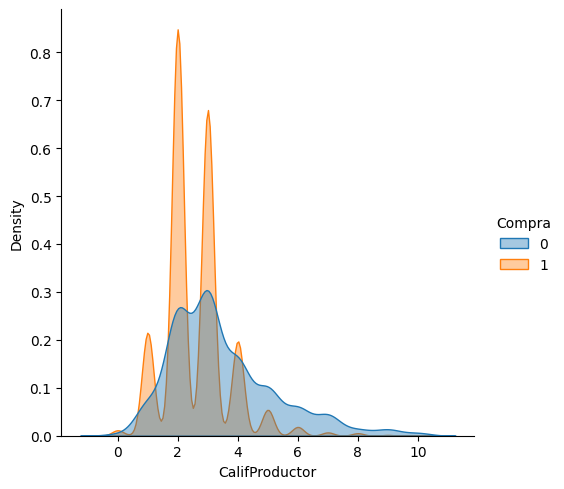

In [14]:
plt.clf()
#sns.kdeplot(vinosDep,x="CalifProductor", hue="Compra", fill=True, common_norm=False, alpha=0.4)
sns.displot(vinosDep, x="CalifProductor", hue="Compra",kind="kde",fill=True, common_norm=False, alpha=0.4)
#sns.histplot(y='CalifProductor',color='Compra',data=vinosDep,palette='viridis')
plt.show()


<Figure size 640x480 with 0 Axes>

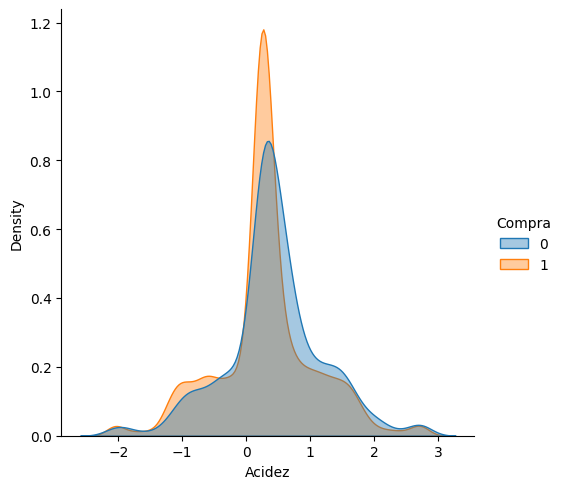

In [15]:
plt.clf()
#sns.kdeplot(vinosDep,x="Acidez", hue="Compra", fill=True, common_norm=False, alpha=0.4)
sns.displot(vinosDep, x="Acidez", hue="Compra", kind="kde",fill=True, common_norm=False, alpha=0.4)
#sns.histplot(y='CalifProductor',color='Compra',data=vinosDep,palette='viridis')
plt.show()


<Figure size 640x480 with 0 Axes>

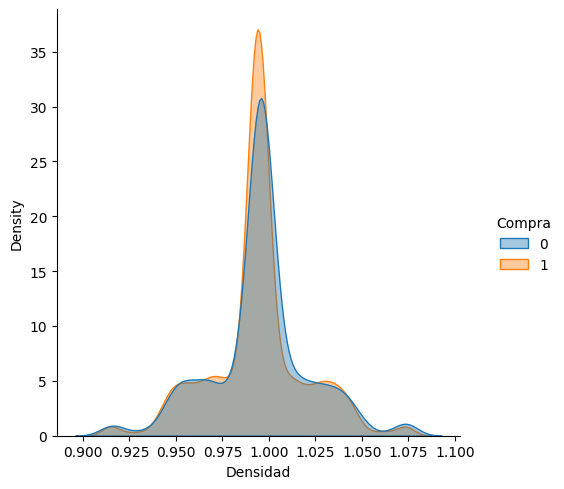

In [16]:
plt.clf()
#sns.kdeplot(vinosDep,x="Densidad", hue="Compra", fill=True, common_norm=False, alpha=0.4)
sns.displot(vinosDep, x="Densidad", hue="Compra",kind="kde",fill=True, common_norm=False, alpha=0.4)
#sns.histplot(y='CalifProductor',color='Compra',data=vinosDep,palette='viridis')
plt.show()


Just to verify that Cramér's V doesn't lie, we test with density and the result is that the overlap of the distributions of 0 and 1 is almost complete. In the case of Acidity, there is a slight difference in distributions that may translate into a minimal effect in the model (we'll see...).


# Logistic Regression Models for the Prediction of the "Compra" Variable
In this section, different logistic regression models are fitted to predict wine purchase. First, we take the training partition (where we fit the model) and the test partition (where we evaluate its performance).

In [17]:
vinosDep.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6365 entries, 0 to 6364
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   ID              6365 non-null   int64   
 1   Acidez          6365 non-null   float64 
 2   AcidoCitrico    6365 non-null   float64 
 3   Azucar          6365 non-null   float64 
 4   CloruroSodico   6365 non-null   float64 
 5   Densidad        6365 non-null   float64 
 6   pH              6365 non-null   float64 
 7   Sulfatos        6365 non-null   float64 
 8   Alcohol         6365 non-null   float64 
 9   CalifProductor  6365 non-null   int64   
 10  PrecioBotella   6365 non-null   float64 
 11  Etiqueta        6365 non-null   category
 12  Clasificacion   6365 non-null   category
 13  Region          6365 non-null   category
 14  n_missings      6365 non-null   int64   
 15  Beneficio       6365 non-null   int64   
 16  Compra          6365 non-null   category
 17  aleatorio       636

In [18]:
vinosDep.Compra.value_counts(normalize=True)

,proportion
Compra,
1,0.785232
0,0.214768


In this case, we have an imbalance situation towards 1s since the prior frequency of 1 is 78%. The model will have greater difficulty recognizing the 0s. Given this, if we get an accuracy of 0.78... we can be suspicious and we will carefully examine sensitivity and specificity to put our minds at ease.



## Training-test partition




In [19]:
from sklearn.model_selection import train_test_split

# Creamos 4 objetos: predictores para tr y tst y variable objetivo para tr y tst.
X_train, X_test, y_train, y_test = train_test_split(imputDep, varObjBin, test_size=0.2, random_state=1234)

# Shape
print('Training dataset shape:', X_train.shape, y_train.shape)
print('Testing dataset shape:', X_test.shape, y_test.shape)

Training dataset shape: (5092, 16) (5092,)
Testing dataset shape: (1273, 16) (1273,)


In [20]:
# Training
print(y_train.value_counts(normalize=True))

# Test
y_test.value_counts(normalize=True)


Compra
1    0.784171
0    0.215829
Name: proportion, dtype: float64


,proportion
Compra,
1,0.789474
0,0.210526


# Full Reference Model

We start with our full reference model that includes all variables, with the precaution of not considering ID since it does not contribute any relationship.



In [21]:
data_train = X_train.join(y_train.astype('int64'))

In [22]:
data_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5092 entries, 3574 to 2863
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   Acidez          5092 non-null   float64 
 1   AcidoCitrico    5092 non-null   float64 
 2   Azucar          5092 non-null   float64 
 3   CloruroSodico   5092 non-null   float64 
 4   Densidad        5092 non-null   float64 
 5   pH              5092 non-null   float64 
 6   Sulfatos        5092 non-null   float64 
 7   Alcohol         5092 non-null   float64 
 8   CalifProductor  5092 non-null   int64   
 9   PrecioBotella   5092 non-null   float64 
 10  Etiqueta        5092 non-null   category
 11  Clasificacion   5092 non-null   category
 12  Region          5092 non-null   category
 13  n_missings      5092 non-null   int64   
 14  aleatorio       5092 non-null   float64 
 15  aleatorio2      5092 non-null   float64 
 16  Compra          5092 non-null   int64   
dtypes: category(3), 

In [23]:
# Aplicamos a fórmula de modelo completo
formC=ols_formula(data_train,'Compra')
formC

'Compra ~ Acidez + AcidoCitrico + Azucar + CloruroSodico + Densidad + pH + Sulfatos + Alcohol + CalifProductor + PrecioBotella + Etiqueta + Clasificacion + Region + n_missings + aleatorio + aleatorio2'

In [24]:
vinosDep.Compra=vinosDep.Compra.astype('int64')

We are going to skip the training-test partition and model with the full data. In the end, we will test using CV.

Our functions will then perform the partitioning.


In [25]:
from statsmodels.formula.api import logit

# Ensure 'Clasificacion' is merged and 'Compra' is int64 in vinosDep before fitting
# vinosDep.Clasificacion.replace(['**','***','****'],'**+',inplace=True)
vinosDep.Compra = vinosDep.Compra.astype('int64')

modeloCompleto = logit(formC,data=vinosDep).fit()
print(modeloCompleto.summary())

         Current function value: 0.298916
         Iterations: 35
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6341
Method:                           MLE   Df Model:                           23
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4254
Time:                        12:04:28   Log-Likelihood:                -1902.6
converged:                      False   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.9884      1.617      3.085      0.002       1.819       8.157
Etiqueta[T.M]            -0.4042

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



It is immediately apparent that there are many non-significant effects, at first glance, the giant errors for classifications *** and **** are suspicious. Note that the estimated parameter of 21 or 23 turns out to be the largest of all... In all probability, this is due to the lack of instances of these categories with purchase = 0. Let's remember that the incidence was already low and we have taken a partition of the data... which worsens the situation.

Let's take a look at the distribution of the cross table of Classification and the target variable in vinosDep.


In [26]:
pd.crosstab(vinosDep.Compra, vinosDep.Clasificacion)

Clasificacion,Desc,*,**,***,****
Compra,,,,,
0,1015,306,46,0,0
1,665,1229,1708,1074,322


Well... not a single instance with purchase = 0 and a classification of *** or ****. This generates that high error. The big problem with this will be the model's interpretability. We must consider that the OR (how much more likely the event is to occur than the non-event given a premise) is the exponential of the parameter... if this parameter is 20, we are looking at an OR of 485,165,195, which is difficult to interpret. For this reason, and given that one of the strengths of regressions is interpretation, we decide to merge categories.



In [27]:
# Unimos la categorías problemáticas de Clasificacion
#imputDep.Clasificacion.replace(['**','***','****'],'**+',inplace=True)
vinosDep.Clasificacion.replace(['**','***','****'],'**+',inplace=True)


# # Actualizar la partición
# X_train, X_test, y_train, y_test = train_test_split(imputDep, varObjBin, test_size=0.2, random_state=1234)

# # Genero el training con la objetivo dentro
# data_train = X_train.join(y_train.astype('int64'))
# data_test = X_test.join(y_test.astype('int64'))

# Volver a ajustar el modelo inicial
modeloCompleto = logit(formC,data=vinosDep).fit()
print(modeloCompleto.summary())


# Volver a ajustar el modelo inicial en test para valorar pseudo R2
# modeloCompleto = logit(formC,data=data_test).fit()
# modeloCompleto.summary()


Optimization terminated successfully.
         Current function value: 0.303626
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6343
Method:                           MLE   Df Model:                           21
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4163
Time:                        12:04:28   Log-Likelihood:                -1932.6
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.8876      1.615      3.027      0.002       1.723       8.052

In [28]:
modeloEti= logit('Compra~Etiqueta+Clasificacion',data=vinosDep).fit()
print(modeloEti.summary())

Optimization terminated successfully.
         Current function value: 0.324772
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6358
Method:                           MLE   Df Model:                            6
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.3757
Time:                        12:04:28   Log-Likelihood:                -2067.2
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.4423      0.176      2.518      0.012       0.098       0.787

## Metrics in training-test



In [29]:
import patsy

data_test = X_test.join(y_test.astype('int64'))

# Generamos las matrices de diseño según la fórmula de modelo completo
y_tr, X_tr = patsy.dmatrices(formC, data_train, return_type='dataframe')

# Generamos las matrices de diseño según la fórmula de modelo completo para test
y_tst, X_tst = patsy.dmatrices(formC, data_test, return_type='dataframe')


In [30]:
y_tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5092 entries, 3574 to 2863
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Compra  5092 non-null   float64
dtypes: float64(1)
memory usage: 79.6 KB


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# Definición de modelo
modelo = LogisticRegression(solver='lbfgs', max_iter=1000, penalty=None)

# Arreglar y para que le guste a sklearn...numeric
y_tr_ = y_tr.Compra#.ravel()

# Ajuste de modelo
modelLog = modelo.fit(X_tr,y_tr_)

# Accuracy del modelo en training
acc = modelLog.score(X_tr,y_tr_)
print(acc)

# Predicciones en test
y_pred = modelLog.predict(X_tst)

# Matriz de confusion de clasificación
print(metrics.confusion_matrix(y_tst,y_pred))

# Reporte de clasificación
print(metrics.classification_report(y_tst,y_pred))

# Extraemos el Area bajo la curva ROC
metrics.roc_auc_score(y_tr, modelLog.predict_proba(X_tr)[:, 1])


0.8599764336213669
[[176  92]
 [ 89 916]]
              precision    recall  f1-score   support

         0.0       0.66      0.66      0.66       268
         1.0       0.91      0.91      0.91      1005

    accuracy                           0.86      1273
   macro avg       0.79      0.78      0.79      1273
weighted avg       0.86      0.86      0.86      1273



np.float64(0.9106160986457875)

# Manual Forward Process

We are going to consider a model with the top 3 variables since they show a considerably higher importance than the rest.


In [32]:
form1 = 'Compra ~ Clasificacion + CalifProductor + pH'

# Ajustar modelo 1
modelo1 = logit(form1,data=vinosDep).fit()
print(modelo1.summary())


Optimization terminated successfully.
         Current function value: 0.315443
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6360
Method:                           MLE   Df Model:                            4
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.3936
Time:                        12:04:29   Log-Likelihood:                -2007.8
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.5828      0.223      7.103      0.000       1.146       2.020

This model is simple and quite significant in terms of its parameters. On the other hand, the pseudoR2 on training drops a little but increases on test, which may indicate a greater ability to generalize to unseen data. It looks promising, but it will need to be tested in cross-validation since under the training/test scheme we are still exposed to the randomness of the partition selection.


In [33]:
form2 = 'Compra ~ Clasificacion*Etiqueta + CalifProductor + pH'

# Ajustar modelo 1
modelo2 = logit(form2,data=vinosDep).fit()
print(modelo2.summary())


Optimization terminated successfully.
         Current function value: 0.302270
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6348
Method:                           MLE   Df Model:                           16
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4189
Time:                        12:04:29   Log-Likelihood:                -1923.9
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               2.5289      0.313 

### Wines with a 2+ star Classification

- If the label is MM (reference level of Label), its coefficient is 3.07, meaning the purchase probability of this type of wine is exp(3.07) times higher than that of wines with an Unknown classification and MM label.
- If the label is M, its coefficient will be 3.07-0.408+0.12, that is, betaClas2star + betaLabelM + betaClas2star:LabelM. So the effect will be exp(3.07-0.408+0.12)=exp(2.78), lower than the previous one. Thus, the purchase probability of a wine with a 2-star classification and a bad label is exp(2.78) times higher than that of a wine with an Unknown classification and MM label (reference levels of both variables).


This is the idea behind interactions. As can be sensed, the interpretation becomes quite complex, but interesting real-world patterns can be captured without the constraint of ceteris paribus.

Let's try removing this interaction and replacing it with a couple of continuous variables to obtain a simpler model and later evaluate whether the increase in complexity from the interactions is worth the effort.


In [34]:
form3 = 'Compra ~  Clasificacion + CalifProductor + pH + Etiqueta'

# Ajustar modelo 1
modelo3 = logit(form3,data=vinosDep).fit()
print(modelo3.summary())


Optimization terminated successfully.
         Current function value: 0.306542
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6356
Method:                           MLE   Df Model:                            8
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4107
Time:                        12:04:29   Log-Likelihood:                -1951.1
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.3708      0.286      8.296      0.000       1.811       2.931

The model has half the parameters of the previous one and its performance under the training/test scheme is very similar. In fact, a slight increase in the test pseudoR2 is observed.

Let's introduce another couple of continuous variables that may have an influence, in order to assess their contribution to the model's predictive capacity and the statistical significance of these potential effects.


In [35]:
form4 = 'Compra ~  Clasificacion + CalifProductor + pH + Etiqueta + CloruroSodico'

# Ajustar modelo 1
modelo4 = logit(form4,data=vinosDep).fit()
print(modelo4.summary())


Optimization terminated successfully.
         Current function value: 0.305900
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6355
Method:                           MLE   Df Model:                            9
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4120
Time:                        12:04:29   Log-Likelihood:                -1947.1
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.3854      0.286      8.352      0.000       1.826       2.945

In [36]:
form5 = 'Compra ~  Clasificacion + CalifProductor + pH + Etiqueta + Acidez'

# Ajustar modelo 1
modelo5 = logit(form5,data=vinosDep).fit()
print(modelo5.summary())


Optimization terminated successfully.
         Current function value: 0.305748
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6355
Method:                           MLE   Df Model:                            9
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4123
Time:                        12:04:29   Log-Likelihood:                -1946.1
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4144      0.287      8.417      0.000       1.852       2.977

In [37]:
form6 = 'Compra ~  Clasificacion + Etiqueta + CalifProductor + pH + CloruroSodico + Acidez'

# Ajustar modelo 6
modelo6 = logit(form6,data=vinosDep).fit()
print(modelo6.summary())


Optimization terminated successfully.
         Current function value: 0.305092
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6354
Method:                           MLE   Df Model:                           10
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4135
Time:                        12:04:30   Log-Likelihood:                -1941.9
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4294      0.287      8.475      0.000       1.868       2.991

In [38]:
form7 = 'Compra ~ Acidez + AcidoCitrico + Azucar + CloruroSodico + Densidad + pH + Sulfatos + Alcohol + CalifProductor + PrecioBotella + Etiqueta + Clasificacion + Region'

# Ajustar modelo 7
modelo7 = logit(form7,data=vinosDep).fit()
print(modelo7.summary())


Optimization terminated successfully.
         Current function value: 0.304442
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6346
Method:                           MLE   Df Model:                           18
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4148
Time:                        12:04:30   Log-Likelihood:                -1937.8
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                4.6633      1.605      2.905      0.004       1.517       7.810

# Cross Validation

In [39]:
vinosDep.Compra = vinosDep.Compra.astype('int64')

# Apply formula
cross_val_log(form7,data=vinosDep)


Modelo: Compra ~ Acidez + AcidoCitrico + Azucar + CloruroSodico + Densidad + pH + Sulfatos + Alcohol + CalifProductor + PrecioBotella + Etiqueta + Clasificacion + Region
AUC: 0.904 (0.008)


array([0.89162121, 0.91214201, 0.90533333, 0.91189744, 0.89816724,
       0.91418173, 0.90630521, 0.90707135, 0.8888315 , 0.89994505,
       0.90200254, 0.90547616, 0.90315085, 0.89731665, 0.9117146 ,
       0.90876865, 0.89073794, 0.89999337, 0.90937004, 0.90655857,
       0.89717641, 0.89799687, 0.9022381 , 0.91235678, 0.90751467,
       0.89395932, 0.90653811, 0.90348686, 0.90890891, 0.90463602,
       0.90776147, 0.90486298, 0.88809294, 0.90270677, 0.91635413,
       0.90464493, 0.9057426 , 0.90770746, 0.89793293, 0.90369446,
       0.90520662, 0.90874816, 0.91321387, 0.91205546, 0.88059894,
       0.90789095, 0.91174751, 0.90021433, 0.90039166, 0.89766806,
       0.91640634, 0.90869734, 0.89579041, 0.89208788, 0.9051499 ,
       0.89377805, 0.9021841 , 0.8916442 , 0.91575865, 0.91388058,
       0.89954748, 0.90617456, 0.90320778, 0.90378284, 0.90671707,
       0.90655857, 0.89186223, 0.89903285, 0.90276579, 0.91555407,
       0.89802075, 0.90512776, 0.90639886, 0.90680585, 0.89881

Creamos lista de fórmulas y aplicamos de froma general la comparativa por CV.



In [40]:
list_form = [formC,form1,form2,form3,form4,form5,form6,form7]
#list_form

list_res = pd.DataFrame(map(lambda x: cross_val_log(x,vinosDep, seed=2022),list_form))


Modelo: Compra ~ Acidez + AcidoCitrico + Azucar + CloruroSodico + Densidad + pH + Sulfatos + Alcohol + CalifProductor + PrecioBotella + Etiqueta + Clasificacion + Region + n_missings + aleatorio + aleatorio2
AUC: 0.904 (0.008)
Modelo: Compra ~ Clasificacion + CalifProductor + pH
AUC: 0.898 (0.008)
Modelo: Compra ~ Clasificacion*Etiqueta + CalifProductor + pH
AUC: 0.907 (0.007)
Modelo: Compra ~  Clasificacion + CalifProductor + pH + Etiqueta
AUC: 0.903 (0.008)
Modelo: Compra ~  Clasificacion + CalifProductor + pH + Etiqueta + CloruroSodico
AUC: 0.903 (0.008)
Modelo: Compra ~  Clasificacion + CalifProductor + pH + Etiqueta + Acidez
AUC: 0.904 (0.008)
Modelo: Compra ~  Clasificacion + Etiqueta + CalifProductor + pH + CloruroSodico + Acidez
AUC: 0.904 (0.008)
Modelo: Compra ~ Acidez + AcidoCitrico + Azucar + CloruroSodico + Densidad + pH + Sulfatos + Alcohol + CalifProductor + PrecioBotella + Etiqueta + Clasificacion + Region
AUC: 0.904 (0.008)


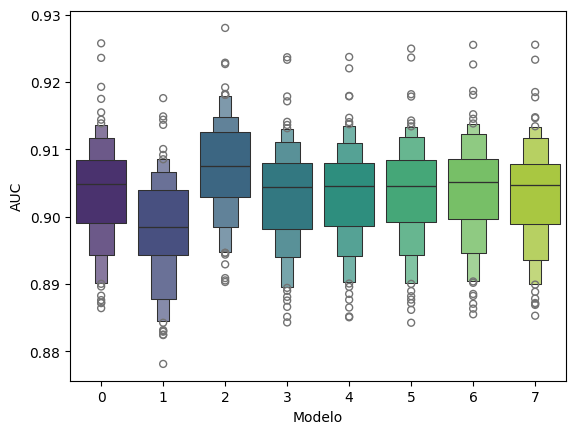

In [41]:
results = list_res.T.melt()
results.columns = ['Modelo','AUC']
results.head()

# Boxplot
plt.clf()
sns.boxenplot(x='Modelo',y='AUC',data=results,palette='viridis')
plt.show()


All of them are good models since they have an ROC of 0.9. Among them, the differences are very, very slight, so the final decision will depend on their complexity. It will always be tempting to opt for the best ones (by thousandths), such as the models that include the Classification and Label interactions (this is due to the scale of the boxplot, because if the axis started at 0 we probably wouldn't even notice the difference).

It doesn't seem like a bad idea to go with a more complex model, but once evaluated (fitted on the full model and the ORs assessed), the interaction loses statistical significance and therefore the ORs do as well. That is why I opt for the form3 model, which is the simplest one and has very similar predictive capacity to the rest.




# Optimal Cutoff Point for the Estimated Probability




In [42]:
metrics.get_scorer_names()

['accuracy',
 'adjusted_mutual_info_score',
 'adjusted_rand_score',
 'average_precision',
 'balanced_accuracy',
 'completeness_score',
 'd2_absolute_error_score',
 'explained_variance',
 'f1',
 'f1_macro',
 'f1_micro',
 'f1_samples',
 'f1_weighted',
 'fowlkes_mallows_score',
 'homogeneity_score',
 'jaccard',
 'jaccard_macro',
 'jaccard_micro',
 'jaccard_samples',
 'jaccard_weighted',
 'matthews_corrcoef',
 'mutual_info_score',
 'neg_brier_score',
 'neg_log_loss',
 'neg_max_error',
 'neg_mean_absolute_error',
 'neg_mean_absolute_percentage_error',
 'neg_mean_gamma_deviance',
 'neg_mean_poisson_deviance',
 'neg_mean_squared_error',
 'neg_mean_squared_log_error',
 'neg_median_absolute_error',
 'neg_negative_likelihood_ratio',
 'neg_root_mean_squared_error',
 'neg_root_mean_squared_log_error',
 'normalized_mutual_info_score',
 'positive_likelihood_ratio',
 'precision',
 'precision_macro',
 'precision_micro',
 'precision_samples',
 'precision_weighted',
 'r2',
 'rand_score',
 'recall',
 're

In [43]:
imputDep.Clasificacion.replace(['**','***','****'],'**+',inplace=True)

# Creamos 4 objetos: predictores para tr y tst y variable objetivo para tr y tst.
X_train, X_test, y_train, y_test = train_test_split(imputDep, varObjBin, test_size=0.2, random_state=1234)

data_train = X_train.join(y_train.astype('int64'))
data_test = X_test.join(y_test.astype('int64'))

# Ajustar modelo 5
modelo5 = logit(form5,data=data_train).fit()
print(modelo5.summary())

Optimization terminated successfully.
         Current function value: 0.307269
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 5092
Model:                          Logit   Df Residuals:                     5082
Method:                           MLE   Df Model:                            9
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4109
Time:                        12:07:47   Log-Likelihood:                -1564.6
converged:                       True   LL-Null:                       -2655.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4577      0.320      7.669      0.000       1.830       3.086

In [44]:
y_pred = modelo5.predict(X_test)
y_pred.describe()

,0
count,1273.000000
mean,0.773766
std,0.273719
min,0.015803
25%,0.574831
50%,0.924177
75%,0.987087
max,0.998460


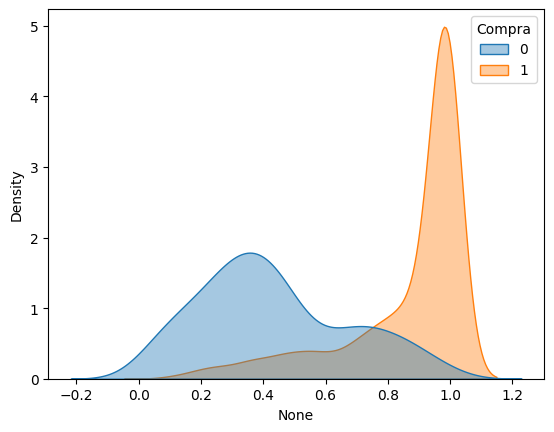

In [45]:
## Buscamos el mejor punto de corte

y_pred = modelo5.predict(X_test)

#sns.histplot(x=y_pred, hue=y_test)
#px.histogram(x=y_pred, color=y_test).show()
#gráfico de las probabilidades obtenidas
plt.clf()
sns.kdeplot(x=y_pred, hue=y_test, fill=True, common_norm=False, alpha=0.4)
plt.show()
#hist_targetbinaria(predict(modelo4, newdata=data_test,type="response"),data_test$varObjBin,"probabilidad")


In [46]:
y_pred.describe()

,0
count,1273.000000
mean,0.773766
std,0.273719
min,0.015803
25%,0.574831
50%,0.924177
75%,0.987087
max,0.998460


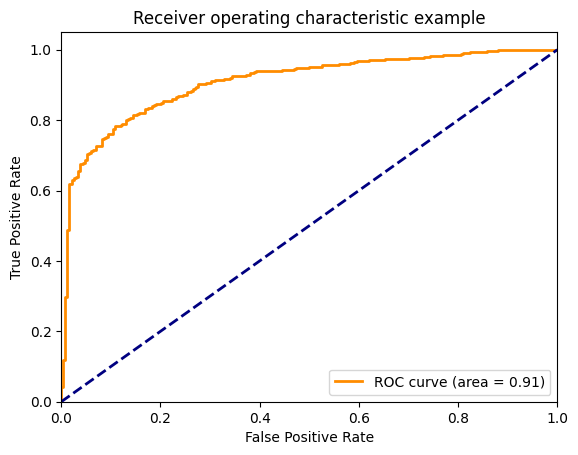

In [47]:
def roc_grafico(test,pred):
    fpr, tpr, thresholds = metrics.roc_curve(test,pred)
    roc_auc = metrics.auc(fpr, tpr)

    plt.figure()
    lw = 2
    plt.plot(
        fpr,
        tpr,
        color="darkorange",
        lw=lw,
        label="ROC curve (area = %0.2f)" % roc_auc,
    )
    plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver operating characteristic example")
    plt.legend(loc="lower right")
    plt.show()

roc_grafico(y_test,y_pred)


Okay, here are the results. With the cutoff point at 0.5, the accuracy is 0.85 (85% of individuals correctly classified). However, the specificity (ability to classify the 0s) is at 61.9%, meaning almost 40% of false positives are being produced — individuals the model classifies as 1 but are actually 0... This value is very low... poor 0s...

With the cutoff point at 0.75, the accuracy decreases slightly (something natural since you can't maximize everything at once), but the specificity increases to 0.85, only 15% of false positives. However, sensitivity (ability to classify the 1s) is sacrificed, dropping from 0.91 to 0.82.

There is the Youden index, which jointly maximizes the relationship between sensitivity and specificity with a simple additive formula: sens + spec - 1.

In [48]:
# Aplicar corte de youden (NuestrasFunciones)
corte = cutoff_youden(y_test,y_pred)
corte


np.float64(0.771424395023577)

In [49]:
# Vemos los coeficientes del modelo ganador
print(modelo5.summary())


                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 5092
Model:                          Logit   Df Residuals:                     5082
Method:                           MLE   Df Model:                            9
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4109
Time:                        12:07:48   Log-Likelihood:                -1564.6
converged:                       True   LL-Null:                       -2655.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4577      0.320      7.669      0.000       1.830       3.086
Clasificacion[T.*]       1.7980      0.097     18.609      0.000       1.609       1.987
Clasificacio

# Confusion Matrix

We compare confusion matrices with the default cutoff point (0.5) and the Youden cutoff point.

Confusion matrix (default cutoff point 0.5)

In [50]:
y_pred = modelo5.predict(X_test)
round(y_pred)

,0
2944,1.0
2258,1.0
3221,0.0
1070,1.0
1806,1.0
...,...
1624,1.0
2815,1.0
3512,1.0
4615,1.0


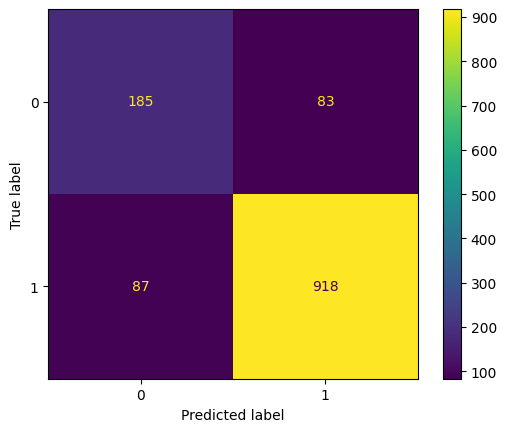

In [51]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = modelo5.predict(X_test)
cm = confusion_matrix(y_test, round(y_pred))

cm_display = ConfusionMatrixDisplay(cm).plot()
cm_display
plt.show()


In [52]:
# Reporte de clasificación
print(metrics.classification_report(y_test,round(y_pred)))


              precision    recall  f1-score   support

           0       0.68      0.69      0.69       268
           1       0.92      0.91      0.92      1005

    accuracy                           0.87      1273
   macro avg       0.80      0.80      0.80      1273
weighted avg       0.87      0.87      0.87      1273



The model correctly identifies 918 out of 1,005 positives (1) and 185 out of 268 negatives (0).

**Confusion matrix (optimal cutoff point by Youden)**

In [58]:
corte = cutoff_youden(y_test,y_pred)
corte

np.float64(0.7760931357266556)

Youden tells us to set the cutoff point to 0.77 but we can slightly adjust it by watching the scores in the confusion matrix.



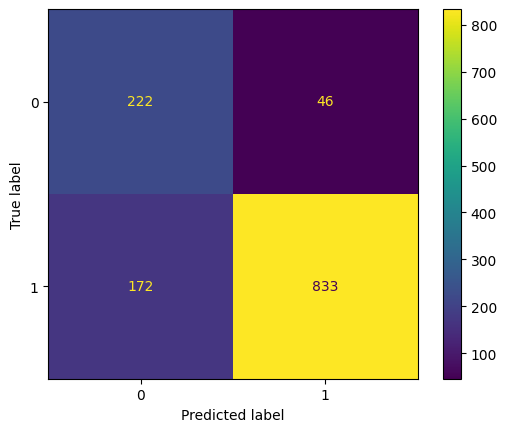

In [53]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = modelo3.predict(X_test)
y_clas =  y_pred.map(lambda x: 1 if x > 0.71 else 0)

cm = confusion_matrix(y_test, y_clas)

cm_display = ConfusionMatrixDisplay(cm).plot()
cm_display
plt.show(cm_display)


The model correctly identifies 833 out of 1,005 positives (1) and 222 out of 268 negatives (0).


In [54]:
# Reporte de clasificación
print(metrics.classification_report(y_test,y_clas))


              precision    recall  f1-score   support

           0       0.56      0.83      0.67       268
           1       0.95      0.83      0.88      1005

    accuracy                           0.83      1273
   macro avg       0.76      0.83      0.78      1273
weighted avg       0.87      0.83      0.84      1273



#Interpretation of the Logistic Model Parameters
For model interpretation, it is best to do it on the full data since the estimators will be more robust as they are based on a larger number of observations.


In [55]:
varObjBin

,Compra
0,1
1,1
2,0
3,1
4,1
...,...
6360,0
6361,1
6362,1
6363,1


In [56]:
vinosDep = pd.concat([imputDep,varObjBin.astype('int64')], axis=1)
vinosDep["Clasificacion"] = vinosDep["Clasificacion"].cat.reorder_categories(['Desc','*','**+'])
modeloF = logit(form5,data=vinosDep).fit()
print(modeloF.summary())


Optimization terminated successfully.
         Current function value: 0.305748
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                 Compra   No. Observations:                 6365
Model:                          Logit   Df Residuals:                     6355
Method:                           MLE   Df Model:                            9
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.4123
Time:                        12:07:48   Log-Likelihood:                -1946.1
converged:                       True   LL-Null:                       -3311.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                2.4144      0.287      8.417      0.000       1.852       2.977

In [57]:
np.exp(modeloF.params)

,0
Intercept,11.183323
Clasificacion[T.*],6.170091
Clasificacion[T.**+],126.688226
Etiqueta[T.M],0.682250
Etiqueta[T.R],0.376117
Etiqueta[T.B],0.247845
Etiqueta[T.MB],0.182298
CalifProductor,0.653532
pH,0.807835
Acidez,0.847068


### Model conclusions:

- The probability of purchase versus non-purchase of a wine with a Classification of 2 or more stars is 126 times higher than that of wines with an Unknown classification.

- The probability of purchase versus non-purchase of a wine with a 1-star Classification is 6.17 times that of wines with an Unknown classification.

- A unit increase in the Producer Rating produces a 35% decrease in the purchase/non-purchase probability ratio.

- The purchase probability of a wine with an MB Label is reduced by 82% compared to that of a wine with an MM Label.

- Each unit increase in pH produces a 20% reduction in the purchase probability.

- Each unit increase in Acidity produces a 15.3% reduction in the purchase probability.

All these effects are understood in the ceteris paribus context, that is, all else being equal. Therefore, this unit increase in pH produces such a decrease in purchase probability for wines with the same Label, Classification, Acidity, and Producer Rating.